In [37]:
import numpy as np
import cv2

import os
import io

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub  

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
# import tensorflow_datasets as tfds

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')

Num GPUs Available:  1


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [38]:
import kagglehub
import pathlib

# Download dataset
# dataset_path = kagglehub.dataset_download("emmarex/plantdisease")
dataset_path = r"C:\Users\Karylle\Downloads\Plant_leaf_diseases_dataset_without_augmentation\Plant_leave_diseases_dataset_without_augmentation"

data_dir = pathlib.Path(dataset_path)

print("Dataset downloaded to:", data_dir)
print("Dataset contents:", os.listdir(data_dir))

Dataset downloaded to: C:\Users\Karylle\Downloads\Plant_leaf_diseases_dataset_without_augmentation\Plant_leave_diseases_dataset_without_augmentation
Dataset contents: ['Background_without_leaves', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___healthy', 'Potato___Late_blight', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image

image_classes = ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']
print(dataset_path)
print("Dataset folder contents:", os.listdir(dataset_path))
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path): 
        print("Found class:", item)
        # print(os.path.join(dataset_path, "Data"+))


C:\Users\Karylle\Downloads\Plant_leaf_diseases_dataset_without_augmentation\Plant_leave_diseases_dataset_without_augmentation
Dataset folder contents: ['Background_without_leaves', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___healthy', 'Potato___Late_blight', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']
Found class: Background_without_leaves
Found class: Corn___healthy
Found class: Corn___Northern_Leaf_Blight
Found class: Grape___Black_rot
Found class: Grape___Esca_(Black_Measles)
Found class: Grape___healthy
Found class: Peach___Bacterial_spot
Found class: Peach___healthy
Found class: Pepper,_bell___Bacterial_spot
Found class: Pepper,_bell___healthy
Found class: Potato___healthy
F

In [40]:
import tensorflow as tf
import pathlib

dataset_path = pathlib.Path(dataset_path)

full_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    # batch_size=32,
    shuffle=True,
    seed=42
)

total_images = len(full_dataset.file_paths)

# Define split sizes - 75% for training, 15% for validation, 10% for testing
train_size = int(0.75 * total_images)   
valid_size = int(0.15 * total_images)   
test_size = total_images - (train_size + valid_size)  

print(f"Total images: {total_images}, Train: {train_size}, Validation: {valid_size}, Test: {test_size}")

# Training + Validation Dataset (90%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.1667, 
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=4
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.1667,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=4
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=None,  
    seed=42,
    image_size=(224, 224),
    batch_size=4
)

test_dataset = test_dataset.skip(train_size + valid_size)  

Found 25109 files belonging to 18 classes.
Total images: 25109, Train: 18831, Validation: 3766, Test: 2512
Found 25109 files belonging to 18 classes.
Using 20924 files for training.
Found 25109 files belonging to 18 classes.
Using 4185 files for validation.
Found 25109 files belonging to 18 classes.


In [41]:
class_names = train_dataset.class_names
print(class_names)

['Background_without_leaves', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']


In [42]:
class_names = full_dataset.class_names
print(class_names)

class_counts = {}
for images, labels in full_dataset.unbatch():
    label = int(labels.numpy())
    class_counts[label] = class_counts.get(label, 0) + 1

print(sorted(class_counts.items()))

['Background_without_leaves', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']
[(0, 1143), (1, 985), (2, 1162), (3, 1180), (4, 1383), (5, 423), (6, 2297), (7, 360), (8, 997), (9, 1478), (10, 1000), (11, 152), (12, 1109), (13, 456), (14, 2127), (15, 1909), (16, 5357), (17, 1591)]


In [44]:
# Split validation (25%) into validation (15%) and test (10%)
total_batches = len(validation_dataset)
val_batches = int(total_batches * (15 / 25))
test_batches = total_batches - val_batches

valid_dataset = validation_dataset.take(val_batches)
test_dataset = validation_dataset.skip(val_batches)

print(f"Train batches: {len(train_dataset)}")
print(f"Validation batches: {len(valid_dataset)}")
print(f"Test batches: {len(test_dataset)}")

Train batches: 5231
Validation batches: 628
Test batches: 419


In [46]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),  
    tf.keras.layers.RandomRotation(0.3),                    
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    tf.keras.layers.RandomBrightness(factor=0.2),           
])

def preprocess(image, label):
    image = tf.keras.applications.efficientnet_v2.preprocess_input(image)
    return image, label
  
train_set = (train_dataset
    .shuffle(1000)  
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

valid_set = (valid_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_set = (test_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

In [47]:
base_model = tf.keras.applications.EfficientNetV2B0(weights="imagenet",
                                            include_top=False)

In [48]:
for layer in base_model.layers[:100]:
  layer.trainable = False

In [49]:
model = Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(18, activation='softmax')
])

In [50]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    train_set,
    validation_data=valid_set,
    epochs=10,
    callbacks=[early_stopping, lr_scheduler, model_checkpoint],
) 

Epoch 1/10
5231/5231 [==============================] - 338s 62ms/step - loss: 0.6371 - accuracy: 0.8123 - val_loss: 0.1051 - val_accuracy: 0.9638 - lr: 0.0010
Epoch 2/10
5231/5231 [==============================] - 287s 55ms/step - loss: 0.2601 - accuracy: 0.9238 - val_loss: 0.0872 - val_accuracy: 0.9757 - lr: 0.0010
Epoch 3/10
5231/5231 [==============================] - 297s 57ms/step - loss: 0.2028 - accuracy: 0.9443 - val_loss: 0.0527 - val_accuracy: 0.9849 - lr: 0.0010
Epoch 4/10
5231/5231 [==============================] - 393s 75ms/step - loss: 0.1706 - accuracy: 0.9540 - val_loss: 0.0680 - val_accuracy: 0.9861 - lr: 0.0010
Epoch 5/10
5231/5231 [==============================] - 378s 72ms/step - loss: 0.1495 - accuracy: 0.9592 - val_loss: 0.0464 - val_accuracy: 0.9877 - lr: 0.0010
Epoch 6/10
5231/5231 [==============================] - 398s 76ms/step - loss: 0.1380 - accuracy: 0.9622 - val_loss: 0.0766 - val_accuracy: 0.9865 - lr: 0.0010
Epoch 7/10
5231/5231 [==================

In [51]:
# model.evaluate(test_dataset,y_test)
test_loss, test_acc = model.evaluate(test_set, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}") 

419/419 [==============================] - 14s 30ms/step - loss: 0.0158 - accuracy: 0.9952
Test Accuracy: 0.9952


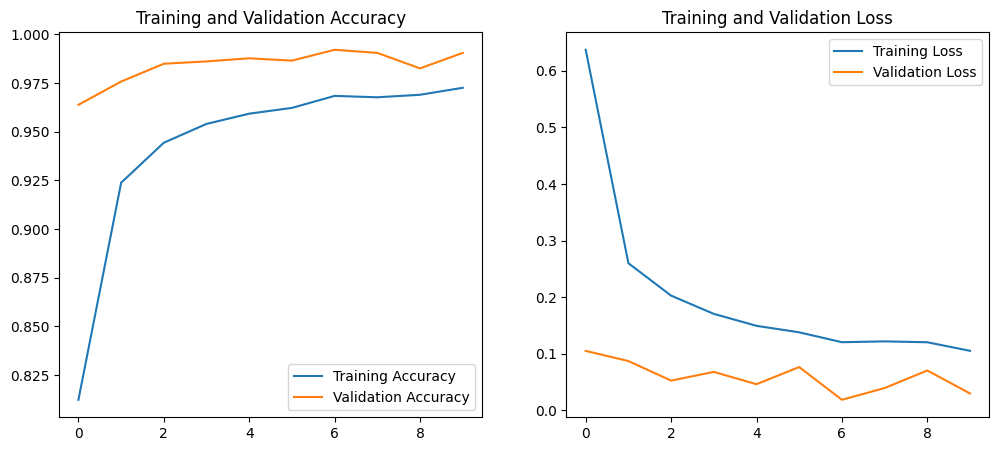

In [52]:
import matplotlib.pyplot as plt

# Extract values from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))    

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


In [53]:
model.save("PlantDiseaseClassifierModelV2.keras")

In [60]:
model.summary()
model = tf.keras.models.load_model("PlantDiseaseClassifierModelV2.keras")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Function  (None, None, None, 1280)  5919312  
 al)                                                             
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_3 (Dropout)         (None, 1280)              0         
                                                                 
 dense_3 (Dense)             (None, 128)               163968    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)               

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub 
import matplotlib.pyplot as plt 

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image

# Load the trained model
model = tf.keras.models.load_model("PlantDiseaseClassifierModelV2.keras") 
image_classes = ['Background_without_leaves', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 
                 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 
                 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 
                 'Pepper,_bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Strawberry___Leaf_scorch', 
                 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Late_blight', 
                 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy']

def predict_and_show(img_path, true_label):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    img_array = tf.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    predictions = model.predict(img_array)
    predicted_index = tf.argmax(predictions[0]).numpy()
    predicted_class = image_classes[predicted_index]
    confidence = predictions[0][predicted_index]

    print(f"Predicted index: {predicted_index}")
    print(f"Predicted class from list: {image_classes[predicted_index]}")

    print(true_label.lower())
    print(predicted_class.lower())
    is_correct = (predicted_class.lower() == true_label.lower())
    result_status = "Correct" if is_correct else "Wrong"

    plt.imshow(img)
    plt.title(
        f"True: {true_label} | Pred: {predicted_class} ({confidence:.2f})\n{result_status}"
    )
    plt.axis('off')
    plt.show()

    print(f"[{result_status}] True: {true_label} — Predicted: {predicted_class} (Confidence: {confidence:.2f})")

predict_and_show(
    r"c:\Users\Karylle\Downloads\tomato-late-blight-tomato-1556463954.jpg",
    true_label="Tomato___Late_blight"
)

predict_and_show(
    r"c:\Users\Karylle\Downloads\northernleafblight2_600px.jpg",
    true_label="Corn___Northern_Leaf_Blight"
)



1/1 [==============================] - 9s 9s/step
Predicted index: 15
Predicted class from list: Tomato___Late_blight
tomato___late_blight
tomato___late_blight


NameError: name 'plt' is not defined

In [ ]:
for img, label in test_dataset.take(1).unbatch().batch(1):
    prediction = model.predict(img)
    predicted_index = tf.argmax(prediction[0])
    print("True label:", image_classes[label.numpy()[0]])
    print("Predicted:", image_classes[predicted_index]) 

1/1 [==============================] - 0s 36ms/step
True label: Grape___Black_rot
Predicted: Grape___Black_rot
1/1 [==============================] - 0s 41ms/step
True label: Grape___Esca_(Black_Measles)
Predicted: Grape___Esca_(Black_Measles)
1/1 [==============================] - 0s 54ms/step
True label: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Predicted: Tomato___Tomato_Yellow_Leaf_Curl_Virus
1/1 [==============================] - 0s 54ms/step
True label: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Predicted: Tomato___Tomato_Yellow_Leaf_Curl_Virus


1/1 [==============================] - 0s 67ms/step


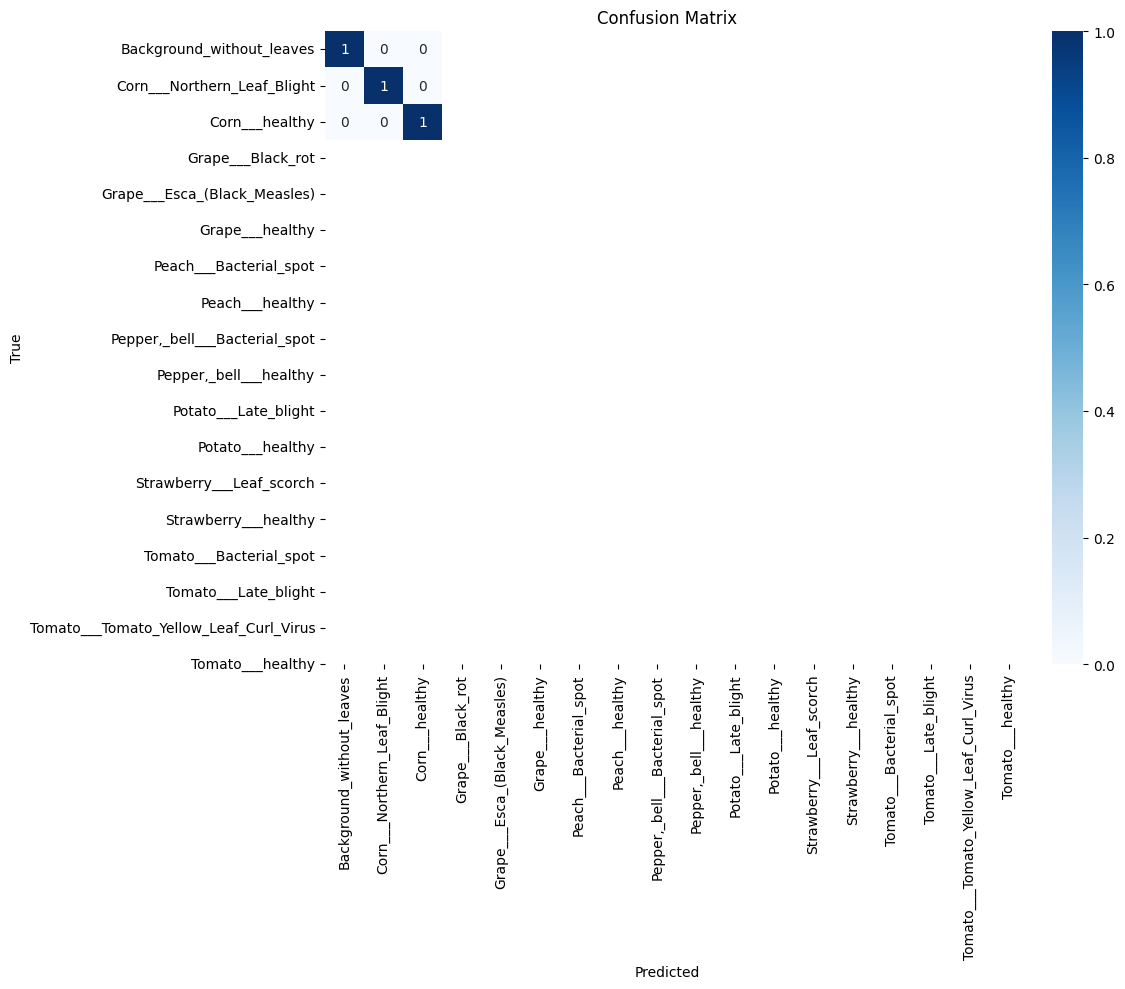

ValueError: Number of classes, 3, does not match size of target_names, 18. Try specifying the labels parameter

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# test_images = [
#     (r"c:\Users\Karylle\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\Potato___healthy\03da9931-e514-4cc7-b04a-8f474a133ce5___RS_HL 1830.JPG", "Potato___healthy"),
#     (r"c:\Users\Karylle\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\Tomato_Late_blight\0ab172fa-ac7b-4a3e-90c8-0708703eb3bb___RS_Late.B 5572.JPG","Tomato___Late_blight"),
#     (r"c:\Users\Karylle\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\Tomato__Tomato_YellowLeaf__Curl_Virus\0a22fcaa-634d-4711-b2a8-777063377543___UF.GRC_YLCV_Lab 03238.JPG","Tomato___Tomato_Yellow_Leaf_Curl_Virus"),
# ]

# y_true = [] 
# y_pred = []

# for path, true_label in test_images:
#     img = image.load_img(path, target_size=(224, 224))
#     img_array = tf.keras.utils.img_to_array(img)
#     img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)
#     img_array = tf.expand_dims(img_array, 0)

#     preds = model.predict(img_array)
#     pred_index = tf.argmax(preds[0]).numpy()
#     y_pred.append(pred_index)
#     y_true.append(image_classes.index(true_label))

# # Confusion matrix
# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(12, 10))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=image_classes, yticklabels=image_classes)
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.xticks(rotation=90)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

# print(classification_report(y_true, y_pred, target_names=image_classes))
